# 实验六：基础 Actor-Critic 算法实现与 Atari 环境测试

## Actor-Critic 背景知识

### 1. 为什么需要 Actor-Critic

在策略梯度方法中，智能体直接学习参数化策略 $\pi_\theta(a\mid s)$。最基础的 REINFORCE 使用完整回报 $G_t$ 评价一次动作：

$$
\nabla_\theta J(\theta)
= \mathbb{E}_{\pi_\theta}\left[
\nabla_\theta \log \pi_\theta(a_t\mid s_t)G_t
\right].
$$

这种方法不需要显式学习动作价值表，但用随机轨迹的回报直接更新策略，方差通常较大，训练曲线容易震荡。Actor-Critic（AC）在策略网络之外再学习一个值函数，用它判断“当前动作的结果比通常预期好多少”，从而降低策略梯度的方差。

### 2. Actor 与 Critic 的分工

- **Actor**表示策略 $\pi_\theta(a\mid s)$。它根据状态输出各离散动作的 logits，经过分类分布采样动作，并根据 advantage 调整动作概率。
- **Critic**近似状态价值 $V_\phi(s)$。它估计从状态 $s$ 出发、继续执行当前策略时能够获得的期望折扣回报。
- **共享编码器**先把原始观测转换为特征，再分别送入策略头和值函数头。在 Atari 图像环境中，共享卷积特征可以减少参数量，也让两个任务共同学习对游戏画面有用的表示。

本实验采用单网络双头结构：

$$
s_t \xrightarrow{\text{shared encoder}} z_t
\begin{cases}
\text{policy head}: & z_t \rightarrow \pi_\theta(\cdot\mid s_t),\\
\text{value head}: & z_t \rightarrow V_\phi(s_t).
\end{cases}
$$

### 3. Advantage 如何连接 Actor 和 Critic

本实验先用一条完整 episode 的奖励计算 Monte Carlo return：

$$
G_t = r_{t+1} + \gamma r_{t+2} + \gamma^2 r_{t+3} + \cdots,
$$

再用 Critic 给出的基线构造 advantage：

$$
A_t = G_t - V_\phi(s_t).
$$

- 当 $A_t>0$ 时，动作结果好于 Critic 的预期，Actor 应提高该动作在当前状态下的概率。
- 当 $A_t<0$ 时，动作结果差于预期，Actor 应降低该动作的概率。
- Critic 则通过拟合 $G_t$，逐步提高自己的价值估计准确度。

从策略损失看，$-\log\pi_\theta(a_t\mid s_t)A_t$ 正是上述更新方向。实现时需要对 Actor 使用的 advantage 停止梯度，否则策略损失会通过 advantage 意外更新 Critic。

### 4. 联合损失与探索

基础 AC 通常联合优化三部分：

$$
\mathcal{L}
= \mathcal{L}_{\pi}
+ c_v\mathcal{L}_V
- c_e\mathcal{H}(\pi_\theta).
$$

- $\mathcal{L}_{\pi}$ 是策略损失，负责更新 Actor。
- $\mathcal{L}_V$ 是价值损失，负责让 Critic 拟合回报。
- $\mathcal{H}$ 是`策略熵`。最大化熵可以避免策略过早集中到少数动作，维持探索。
- $c_v$ 和 $c_e$ 分别控制价值学习与探索项在总损失中的权重。

与 DQN 的 $\epsilon$-greedy 不同，Actor-Critic 的策略本身就是概率分布，因此可以直接采样动作；本实验中的 `epsilon` 始终记录为 0，仅用于复用绘图接口。
#### 策略熵的计算

对于离散动作空间，Actor 输出每个动作的 logit $z_i$，经过 Softmax 后得到动作概率：

$$
p_i = \pi_{\theta}(a_i \mid s) = \frac{\exp(z_i)}{\sum_{j=1}^{|\mathcal{A}|} \exp(z_j)}.
$$

状态 $s$ 下的策略熵为整个动作概率分布的信息熵：

$$
\mathcal{H}\left(\pi_{\theta}(\cdot \mid s)\right)
= -\sum_{i=1}^{|\mathcal{A}|}
\pi_{\theta}(a_i \mid s)
\log \pi_{\theta}(a_i \mid s).
$$
策略越接近确定性分布，熵越接近 $0$；策略越接近均匀分布，熵越大，探索性越强。代码中的 `dist.entropy()` 直接计算上述离散策略熵。对一个回合内各时间步的熵取平均后，定义：
$$
\mathcal{L}_{\mathrm{entropy}}
= -\frac{1}{T}\sum_{t=0}^{T-1}
\mathcal{H}\left(\pi_{\theta}(\cdot \mid s_t)\right).
$$
因此代码使用 `entropy_loss = -entropies_t.mean()`，并将 $c_e\mathcal{L}_{\mathrm{entropy}}$ 加入总损失。最小化总损失等价于鼓励更大的策略熵，从而避免策略过早收敛到单一动作。


### 5. 本实验采用的更新方式及局限

本 notebook 使用“每个 episode 结束后更新一次”的 Monte Carlo Actor-Critic。它结构清晰，适合观察 AC 的核心组成，但也有两个局限：完整回报的方差仍然较大，而且 Atari episode 很长时更新频率偏低。若要获得更稳定、更高效的 Atari 结果，通常还会使用灰度缩放、裁剪、帧堆叠、奖励裁剪、并行环境、n-step return 或 GAE；这些属于本实验之后可以继续扩展的方向。

### Actor-Critic 算法伪代码

```text
输入：环境 Env，折扣因子 gamma，学习率 alpha，
      价值损失系数 c_v，熵正则系数 c_e，训练回合数 N
输出：训练后的共享编码器、策略网络 pi_theta 和价值网络 V_phi

初始化 Actor-Critic 网络参数 theta、phi
初始化 Adam 优化器

for episode = 1, 2, ..., N do
    重置环境，得到初始状态 s
    初始化轨迹缓存 R、LogP、V、H 为空

    for t = 0, 1, ..., T_max - 1 do
        对状态 s 进行预处理并输入共享编码器
        由策略头得到动作 logits，并构造分类分布 pi_theta(. | s)
        由价值头估计状态价值 v = V_phi(s)
        从 pi_theta(. | s) 中采样动作 a
        在环境中执行 a，得到奖励 r、下一状态 s' 和终止标志 done
        保存 r、log pi_theta(a | s)、v 和策略熵 H(pi_theta(. | s))
        令 s <- s'
        if done then
            break
        end if
    end for

    从轨迹末端向前计算 Monte Carlo 折扣回报：
        G_t = r_t + gamma * G_(t+1)，其中轨迹末端 G_T = 0
    对每个时间步计算优势：A_t = G_t - V_phi(s_t)

    计算策略损失：L_policy = -mean(log pi_theta(a_t | s_t) * stop_gradient(A_t))
    计算价值损失：L_value = mean((V_phi(s_t) - G_t)^2)
    计算熵损失：L_entropy = -mean(H(pi_theta(. | s_t)))
    计算总损失：L = L_policy + c_v * L_value + c_e * L_entropy

    清空梯度，对 L 反向传播
    裁剪梯度范数并更新网络参数 theta、phi
end for

返回训练后的 Actor-Critic 网络
```


## 实验目标

1. 基于 Gymnasium 创建 Atari 环境，并提供经典控制环境作为调试回退。
2. 至少测试 `ALE/Freeway-v5`、`ALE/Pong-v5`、`ALE/Breakout-v5` 三个 Atari 环境中的两个。
3. 理解共享编码器、策略头和值函数头。
4. 理解 advantage、policy loss、value loss 和 entropy regularization。
5. 可视化 reward、episode length、loss、动作分布和环境帧。


## 0. 安装依赖

本节配置实验所需的 Python、Gymnasium、PyTorch 和 Atari 环境依赖。先完成环境安装并重启 kernel，可以避免后续因 ALE 未注册、ROM 缺失或版本不兼容而中断实验。


## Python 版本依赖说明

建议课程统一使用 **Python 3.11**。依据当前 PyPI 包元数据：

- `gymnasium` 1.3.0: `Requires-Python >=3.10`
- `torch` 2.12.1: `Requires-Python >=3.10`
- `ale-py` 0.12.0: `Requires-Python >=3.10`
- `AutoROM` 0.6.1: `Requires-Python >=3.7`
- `matplotlib` 3.11.0: `Requires-Python >=3.11`
- `ipython` 9.15.0: `Requires-Python >=3.11`
- `numpy` 2.5.0: `Requires-Python >=3.12`

因此：

- 若使用 Python 3.11，建议安装 `numpy<2.5`，例如 `numpy>=1.26,<2.5`。
- 若使用 Python 3.12，也可以直接安装最新版 NumPy。
- 不建议使用 Python 3.9 或更低版本；Gymnasium、PyTorch、Atari 相关包的新版本已经不再覆盖。

推荐创建环境：

```bash
conda create -n rl-course python=3.11 -y
conda activate rl-course
python -m pip install -U pip
```


In [18]:
# Python 3.11 推荐安装命令：
# %pip install -U "numpy>=1.26,<2.5" matplotlib gymnasium torch

# Python 3.12 也可以使用最新版 NumPy：
# %pip install -U numpy matplotlib gymnasium torch

# Atari 依赖。安装后可能需要重启 kernel。
# %pip install -U "gymnasium[atari,accept-rom-license]" ale-py autorom "autorom[accept-rom-license]"
# !AutoROM --accept-license


## 1. 导入依赖

本节导入数值计算、可视化、环境交互和神经网络训练所需的模块，并自动选择 CUDA 或 CPU 设备。最后导入 `Categorical`，用于把 Actor 输出的 logits 构造成离散动作概率分布。


In [2]:
import math
import random
from collections import Counter, deque
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

try:
    import gymnasium as gym
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("请先安装 gymnasium：%pip install -U gymnasium") from exc

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("请先安装 PyTorch：%pip install -U torch") from exc

plt.style.use("seaborn-v0_8-whitegrid")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Gymnasium:", gym.__version__)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)

from torch.distributions import Categorical


Gymnasium: 1.3.0
PyTorch: 2.12.1+cpu
Device: cpu


## 2. 创建环境


In [3]:
# 至少选择其中两个 Atari 环境进行正式测试。调试时可以先使用 DEBUG_ENV_ID。
ATARI_TEST_ENVS = [
    "ALE/Freeway-v5",
    "ALE/Pong-v5",
    "ALE/Breakout-v5",
]

# TODO：正式实验时，从 ATARI_TEST_ENVS 中选择要运行的环境。
# SELECTED_ENV_ID = "ALE/Freeway-v5"
SELECTED_ENV_ID = ATARI_TEST_ENVS[1]
print("候选 Atari 环境:", ATARI_TEST_ENVS)
print("当前选择:", SELECTED_ENV_ID)


候选 Atari 环境: ['ALE/Freeway-v5', 'ALE/Pong-v5', 'ALE/Breakout-v5']
当前选择: ALE/Pong-v5


In [4]:
ATARI_ENV_CANDIDATES = ["ALE/Freeway-v5", "ALE/Pong-v5", "ALE/Breakout-v5"]
DEBUG_ENV_ID = "CartPole-v1"  # 调试回退环境，不作为 Atari 实验结果


def maybe_register_atari():
    try:
        import ale_py
        if hasattr(gym, "register_envs"):
            gym.register_envs(ale_py)
    except Exception:
        pass


def make_env(env_id=None, render_mode=None):
    maybe_register_atari()
    candidates = [env_id] if env_id else ATARI_ENV_CANDIDATES + [DEBUG_ENV_ID]
    errors = []
    for candidate in candidates:
        if candidate is None:
            continue
        try:
            env = gym.make(candidate, render_mode=render_mode)
            print(f"已创建环境: {candidate}")
            return env, candidate
        except Exception as exc:
            errors.append((candidate, repr(exc)))
    message = "\n".join([f"- {name}: {err}" for name, err in errors])
    raise RuntimeError(f"无法创建候选环境，请检查 Atari 依赖、ROM 与环境 ID。\n{message}")


env, active_env_id = make_env(env_id=SELECTED_ENV_ID)
obs, info = env.reset(seed=2026)
print("active_env_id:", active_env_id)
print("observation shape:", np.asarray(obs).shape)
print("action_space:", env.action_space)
env.close()


已创建环境: ALE/Pong-v5
active_env_id: ALE/Pong-v5
observation shape: (210, 160, 3)
action_space: Discrete(6)


## 3. 可视化与预处理

本节提供训练曲线、动作频次和游戏画面的可视化函数，同时把 NumPy 观测转换为 PyTorch 张量。对于图像观测，代码会把通道移到最前面并将像素从 $[0,255]$ 归一化到 $[0,1]$；对于向量观测，则直接转换为浮点张量。预览代码先用随机策略验证渲染和动作空间是否正常。


已创建环境: ALE/Pong-v5


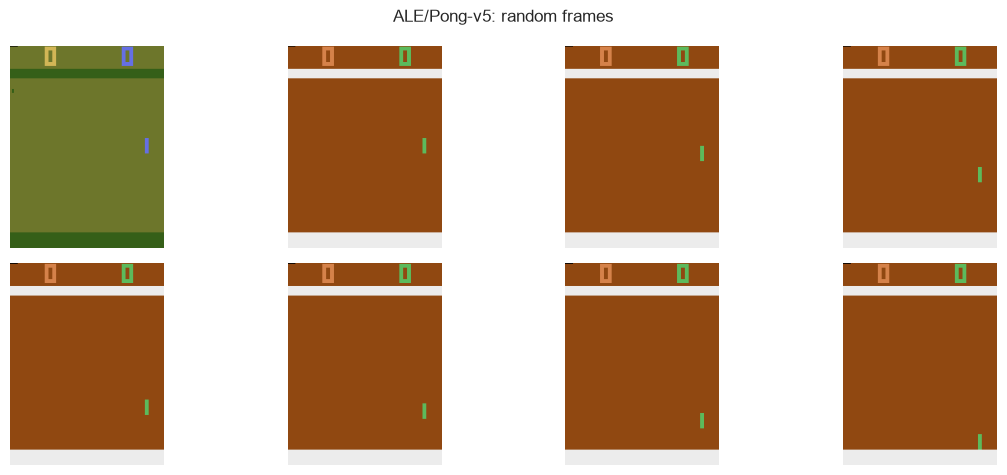

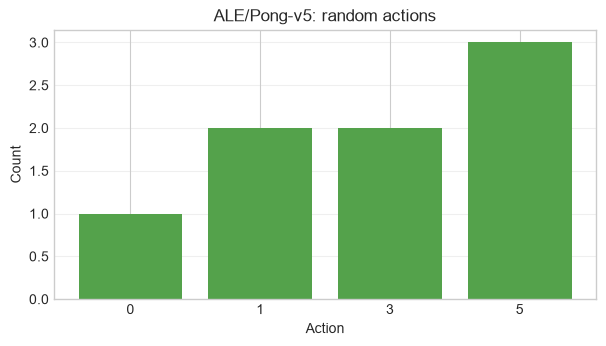

In [5]:
def moving_average(values, window=20):
    values = np.asarray(values, dtype=np.float32)
    if len(values) == 0:
        return values
    window = max(1, int(window))
    if len(values) < window:
        return np.full_like(values, values.mean())
    kernel = np.ones(window, dtype=np.float32) / window
    prefix = np.full(window - 1, values[:window].mean(), dtype=np.float32)
    return np.concatenate([prefix, np.convolve(values, kernel, mode="valid")])


def plot_history(history, title="Training history", window=20):
    if not history or len(history.get("return", [])) == 0:
        print("没有训练历史可视化。")
        return
    fig, axes = plt.subplots(2, 2, figsize=(12, 7))
    items = [("return", "Episode return"), ("length", "Episode length"), ("loss", "Loss"), ("epsilon", "Epsilon")]
    for ax, (key, label) in zip(axes.ravel(), items):
        values = history.get(key, [])
        if len(values) == 0:
            ax.set_title(f"{label} (no data)")
            ax.axis("off")
            continue
        ax.plot(values, alpha=0.25, color="#4C78A8")
        ax.plot(moving_average(values, window), color="#F58518", linewidth=2)
        ax.set_title(label)
        ax.grid(True, alpha=0.3)
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def plot_action_distribution(actions, title="Action distribution"):
    if len(actions) == 0:
        print("没有动作数据可视化。")
        return
    counts = Counter(actions)
    labels = sorted(counts)
    values = [counts[x] for x in labels]
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.bar([str(x) for x in labels], values, color="#54A24B")
    ax.set_title(title)
    ax.set_xlabel("Action")
    ax.set_ylabel("Count")
    ax.grid(True, axis="y", alpha=0.3)
    plt.show()


def plot_frame_grid(frames, title="Environment frames", max_frames=8):
    if not frames:
        print("没有帧数据。")
        return
    frames = frames[:max_frames]
    cols = min(4, len(frames))
    rows = int(math.ceil(len(frames) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 2.4 * rows))
    axes = np.asarray(axes).reshape(-1)
    for ax, frame in zip(axes, frames):
        ax.imshow(frame)
        ax.axis("off")
    for ax in axes[len(frames):]:
        ax.axis("off")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def obs_to_tensor(obs, device=DEVICE):
    arr = np.asarray(obs)
    if arr.ndim == 3:
        if arr.shape[0] not in (1, 3, 4):
            arr = np.transpose(arr, (2, 0, 1))
        arr = arr.astype(np.float32) / 255.0
    else:
        arr = arr.astype(np.float32)
    return torch.as_tensor(arr, device=device).unsqueeze(0)


def batch_obs_to_tensor(obs_batch, device=DEVICE):
    arr = np.asarray(obs_batch)
    if arr.ndim == 4:
        if arr.shape[1] not in (1, 3, 4):
            arr = np.transpose(arr, (0, 3, 1, 2))
        arr = arr.astype(np.float32) / 255.0
    else:
        arr = arr.astype(np.float32)
    return torch.as_tensor(arr, device=device)


def collect_preview_frames(n_steps=8, seed=2026):
    env, env_id = make_env(env_id=SELECTED_ENV_ID,render_mode="rgb_array")
    obs, info = env.reset(seed=seed)
    frames, actions = [], []
    for _ in range(n_steps):
        frame = env.render()
        if frame is not None:
            frames.append(frame)
        action = env.action_space.sample()
        actions.append(int(action))
        obs, reward, terminated, truncated, info = env.step(action)
        if terminated or truncated:
            obs, info = env.reset()
    env.close()
    return env_id, frames, actions


try:
    preview_env_id, preview_frames, preview_actions = collect_preview_frames()
    plot_frame_grid(preview_frames, title=f"{preview_env_id}: random frames")
    plot_action_distribution(preview_actions, title=f"{preview_env_id}: random actions")
except Exception as exc:
    print("预览帧采集失败，可以先继续完成算法代码：", repr(exc))


## 4. Actor-Critic 网络

本节构建 AC 的“共享编码器 + 双输出头”网络，并集中定义训练超参数。网络会根据示例观测自动选择结构：Atari 图像使用卷积编码器，经典控制的向量状态使用多层感知机。策略头输出每个离散动作的 logits，值函数头输出当前状态的标量价值；随后 `compute_discounted_returns` 从 episode 末尾反向计算每个时间步的 Monte Carlo return。

阅读代码时重点关注三件事：观测张量的形状如何决定编码器类型、如何自动推断卷积输出维度，以及策略头和值函数头为什么共享前面的状态表示。


In [6]:
class ActorCriticNet(nn.Module):
    def __init__(self, sample_obs, action_dim):
        super().__init__()
        # 用一条真实观测确定输入形状；先放在 CPU 上，避免初始化阶段发生设备不一致。
        sample = obs_to_tensor(sample_obs, device=torch.device("cpu"))
        # 图像经 obs_to_tensor 处理后为 [batch, channel, height, width]，因此维数为 4。
        self.is_image = sample.ndim == 4
        if self.is_image:
            c, h, w = sample.shape[1:]
            self.encoder = nn.Sequential(
                nn.Conv2d(c, 32, kernel_size=8, stride=4),
                nn.ReLU(),
                nn.Conv2d(32, 64, kernel_size=4, stride=2),
                nn.ReLU(),
                nn.Conv2d(64, 64, kernel_size=3, stride=1),
                nn.ReLU(),
                nn.Flatten(),
            )
            with torch.no_grad():
                hidden_dim = self.encoder(sample).shape[1]
            self.shared = nn.Sequential(nn.Linear(hidden_dim, 256), nn.ReLU())
            shared_dim = 256
        else:
            input_dim = sample.shape[1]
            self.encoder = nn.Identity()
            self.shared = nn.Sequential(
                nn.Linear(input_dim, 128),
                nn.ReLU(),
                nn.Linear(128, 128),
                nn.ReLU(),
            )
            shared_dim = 128

        # Actor 输出 action_dim 个未归一化 logits；Categorical 会在内部完成 softmax。
        self.policy_head = nn.Linear(shared_dim, action_dim)
        # Critic 对每个状态只预测一个标量 V(s)。
        self.value_head = nn.Linear(shared_dim, 1)

    def forward(self, x):
        # 两个任务共享 z，使策略学习和值函数学习都能更新状态编码器。
        z = self.shared(self.encoder(x))
        logits = self.policy_head(z)
        # squeeze(-1) 仅删除末尾大小为 1 的价值维，保留 batch 维。
        value = self.value_head(z).squeeze(-1)
        return logits, value


@dataclass
class ACConfig:
    total_episodes: int = 100
    max_steps_per_episode: int = 1000
    gamma: float = 0.99              # 折扣因子：越大越重视长期奖励。
    lr: float = 1e-4                 # Actor、Critic 和共享编码器使用同一学习率。
    value_coef: float = 0.5          # Critic 损失在总损失中的权重。
    entropy_coef: float = 0.01       # 熵奖励权重，用于维持策略探索。
    grad_clip_norm: float = 10.0     # 梯度范数上限，减轻偶发的大梯度更新。


def compute_discounted_returns(rewards, gamma):
    returns = []
    running = 0.0
    # 从后向前递推 G_t = r_{t+1} + gamma * G_{t+1}，复杂度为 O(T)。
    for reward in reversed(rewards):
        running = float(reward) + gamma * running
        returns.append(running)
    # 上面的结果时间顺序相反，需要翻转后再与各时间步的 value 对齐。
    returns.reverse()
    return torch.as_tensor(returns, dtype=torch.float32, device=DEVICE)


### Actor-Critic 标准损失函数

本实验使用 Monte Carlo return：

$$
G_t = \sum_{k=0}^{T-t-1} \gamma^k r_{t+k+1}
$$

advantage 定义为：

$$
A_t = G_t - V_{\phi}(s_t)
$$

策略损失、值函数损失与 entropy bonus 通常写为：

$$
\mathcal{L}_{\pi}(\theta) = - \mathbb{E}_t \left[\log \pi_{\theta}(a_t \mid s_t) \; \operatorname{stopgrad}(A_t)\right]
$$

$$
\mathcal{L}_{V}(\phi) = \mathbb{E}_t \left[(V_{\phi}(s_t) - G_t)^2\right]
$$

$$
\mathcal{L} = \mathcal{L}_{\pi} + c_v \mathcal{L}_V - c_e \mathbb{E}_t[\mathcal{H}(\pi_{\theta}(\cdot \mid s_t))]
$$

代码中的 `entropy_loss = -entropies_t.mean()` 对应上式中的 entropy bonus 项。因为优化器执行的是梯度下降，把熵的负值加入总损失等价于鼓励更高的策略熵。


## 5. 填空：动作采样与 AC 损失

本节把网络输出转换成一次可训练的决策，并在 episode 结束后计算联合损失。`select_ac_action` 从策略分布采样动作，同时保留该动作的对数概率、状态价值和策略熵；`update_actor_critic` 将整条轨迹堆叠成张量，计算 advantage、Actor 损失、Critic 损失与熵正则项，然后完成一次反向传播。

这里最关键的梯度关系是：`values_t.detach()` 让策略损失把 Critic 预测仅当作基线，而价值损失仍然能够正常训练 Critic。请结合上一单元格的公式检查每个张量是否按同一时间步对齐。


In [7]:
def select_ac_action(model, obs, device=DEVICE):
    # 增加 batch 维并移动到训练设备，输入形状为 [1, ...]。
    obs_t = obs_to_tensor(obs, device)
    logits, value = model(obs_t)
    dist = Categorical(logits=logits)

    # 采样而不是 argmax，使 Actor 能按当前策略概率持续探索。
    action = dist.sample()
    # log_prob 用于策略梯度，entropy 衡量动作分布的随机程度。
    # squeeze(0) 去掉本次单样本决策的 batch 维，便于随后按时间步 stack。
    return int(action.item()), dist.log_prob(action).squeeze(0), value.squeeze(0), dist.entropy().squeeze(0)


def update_actor_critic(model, optimizer, log_probs, values, rewards, entropies, cfg):
    if len(rewards) == 0:
        return None

    # 各列表都按同一条轨迹的时间顺序保存，因此 stack 后第 0 维就是时间维。
    returns = compute_discounted_returns(rewards, cfg.gamma)
    values_t = torch.stack(values)
    log_probs_t = torch.stack(log_probs)
    entropies_t = torch.stack(entropies)

    # detach 阻断 advantage 通过策略损失更新 Critic；Actor 只接收 log_prob 路径的梯度。
    advantages = returns - values_t.detach()
    # 最小化负号后的目标，等价于提高正 advantage 动作的概率、降低负 advantage 动作的概率。
    policy_loss = -(log_probs_t * advantages).mean()
    # Critic 回归 Monte Carlo return，训练 V(s) 成为更准确的策略梯度基线。
    value_loss = F.mse_loss(values_t, returns)
    # 总损失被最小化，因此使用负熵才能实现“最大化熵、鼓励探索”。
    entropy_loss = -entropies_t.mean()
    loss = policy_loss + cfg.value_coef * value_loss + cfg.entropy_coef * entropy_loss

    optimizer.zero_grad() 
    loss.backward()
    # 梯度裁剪，防止梯度爆炸
    torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)
    optimizer.step()
    return float(loss.item())



## 6. 训练 Actor-Critic

本节把环境交互、轨迹缓存、网络更新和指标记录连接成完整训练循环。每个 episode 先重置环境，然后持续采样动作并记录 `reward/log_prob/value/entropy`；episode 结束或达到步数上限后，用整条轨迹更新一次网络，最后保存 return、长度、损失和动作序列并绘图。

观察训练时不要只看单回合 reward。Actor-Critic 的采样具有随机性，应重点比较滑动平均回报是否上升、动作分布是否过早塌缩、episode length 是否符合游戏目标，以及多次随机种子的趋势是否一致。Atari 正式实验至少运行两个环境，并记录所用配置与训练时长。


In [9]:
def train_actor_critic(env_id=None, cfg=ACConfig(), seed=2026):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env, active_env_id = make_env(env_id=env_id)
    obs, info = env.reset(seed=seed)
    # 用环境返回的真实观测初始化网络，动作头维度等于离散动作数量。
    model = ActorCriticNet(obs, env.action_space.n).to(DEVICE)
    optimizer = optim.Adam(model.parameters(), lr=cfg.lr)

    history = {"return": [], "length": [], "loss": [], "epsilon": []}
    all_actions = []

    for episode in range(cfg.total_episodes):
        # 不同 episode 使用不同但可复现的 seed，避免每回合得到完全相同的随机序列。
        obs, info = env.reset(seed=seed + episode)
        rewards, log_probs, values, entropies = [], [], [], []
        episode_return = 0.0

        for step in range(cfg.max_steps_per_episode):
            action, log_prob, value, entropy = select_ac_action(model, obs)
            next_obs, reward, terminated, truncated, info = env.step(action)

            rewards.append(float(reward))
            log_probs.append(log_prob)
            values.append(value)
            entropies.append(entropy)
            all_actions.append(int(action))
            episode_return += float(reward)
            obs = next_obs

            if terminated or truncated:
                break

        # Monte Carlo 更新：收集完整 episode 后只更新一次参数。
        loss = update_actor_critic(model, optimizer, log_probs, values, rewards, entropies, cfg)
        if loss is not None:
            history["loss"].append(loss)
        history["return"].append(episode_return)
        history["length"].append(step + 1)
        history["epsilon"].append(0.0)

        if (episode + 1) % 10 == 0:
            print(f"[AC] episode={episode + 1}, recent_return={np.mean(history['return'][-10:]):.2f}")

    env.close()
    return model, history, all_actions, active_env_id


RUN_AC_TRAINING = False
if RUN_AC_TRAINING:
    cfg = ACConfig(total_episodes=50)
    ac_model, ac_history, ac_actions, ac_env_id = train_actor_critic(env_id=SELECTED_ENV_ID, cfg=cfg, seed=3026)
    plot_history(ac_history, title=f"Actor-Critic on {ac_env_id}", window=10)
    plot_action_distribution(ac_actions, title=f"Actor-Critic actions on {ac_env_id}")
else:
    print("Actor-Critic 训练默认关闭。完成 TODO 后，将 RUN_AC_TRAINING 改为 True。")


Actor-Critic 训练默认关闭。完成 TODO 后，将 RUN_AC_TRAINING 改为 True。


## 训练效果不佳时的诊断与调参建议

建议一次只改变一个因素，至少使用 3 个随机种子比较滑动平均回报，而不是根据单次运行下结论。

### 1. 回报长期无明显提升

- **先增加训练量**：当前 `total_episodes=50` 主要用于代码检查，对像素输入的 Atari 往往远远不够。可先尝试 500–2000 个 episode，并保存中间结果。
- **降低输入难度**：原始 `210 x 160 x 3` 彩色图像计算量大。可加入灰度化、缩放到约 `84 x 84`、帧堆叠和跳帧，使网络更容易识别运动信息。
- **提高奖励信号可学性**：不同 Atari 游戏的奖励尺度差异较大，可尝试把单步奖励裁剪到 $[-1,1]$。注意在报告中同时保留原始 episode return，避免混淆训练奖励和评估奖励。
- **调整学习率**：从 `1e-4` 开始，依次尝试 `3e-4`、`5e-5`、`1e-5`。学习过慢可适当增大，曲线剧烈震荡或突然退化应减小。

### 2. loss 剧烈震荡、出现 NaN 或性能突然崩溃

- 将 `lr` 从 `1e-4` 降到 `5e-5` 或 `1e-5`。
- 将 `grad_clip_norm` 从 `10.0` 收紧到 `5.0` 或 `1.0`，并打印裁剪前的梯度范数辅助判断。
- 对 `advantages` 做标准化：`advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)`。
- 若价值损失远大于策略损失，可降低 `value_coef`；若 Critic 明显学不动，再适当提高。

### 3. 动作分布很快集中到单一动作

- 这通常表示探索过早消失。可把 `entropy_coef` 从 `0.01` 提高到 `0.02` 或 `0.05`。
- 若整个训练过程都接近均匀随机、回报不升，则熵约束可能过强，可降到 `0.005` 或 `0.001`。
- 可以让 `entropy_coef` 随训练逐渐衰减：前期维持探索，后期允许策略变得更确定。
- 同时检查环境的动作含义。某些 Atari 游戏包含功能相近或无效动作，不能仅凭柱状图“不均匀”就判断策略错误。

### 4. Critic 预测不准，advantage 方差很大

- 当前方法每个 episode 才更新一次，长轨迹的 Monte Carlo return 方差较大。可将其扩展为 n-step return，并用末状态价值进行 bootstrap。
- 更进一步可使用 GAE($\lambda$)，常见起点为 `gamma=0.99, lambda=0.95`，在偏差和方差之间取得更稳定的折中。
- 可分别记录 `policy_loss`、`value_loss`、平均 entropy 和 explained variance，而不是只记录总 loss。总 loss 下降并不必然意味着策略回报上升。

### 5. 针对折扣因子与 episode 长度

- `gamma=0.99` 是常用起点。奖励非常延迟时可尝试 `0.995`；任务反馈较即时且训练不稳定时可试 `0.95` 或 `0.98`。
- 如果大量 episode 都以 `max_steps_per_episode` 结束，先区分这是任务表现、环境时间限制还是人为截断。人为截断时，严格的 return 计算应对末状态价值进行 bootstrap，而不是一律把未来价值视为 0。
- `Freeway`、`Pong` 和 `Breakout` 的奖励结构与有效策略差异明显，同一组超参数未必适合所有环境，应分别配置。

### 6. 推荐调参顺序

1. 先在 `CartPole-v1` 验证实现能够稳定学习，但不要把它作为 Atari 实验结果。
2. 对 Atari 加入标准图像预处理，并增加训练 episode 数。
3. 固定其他参数，搜索学习率 `3e-4 / 1e-4 / 5e-5 / 1e-5`。
4. 根据动作熵调整 `entropy_coef`，根据 Critic 误差调整 `value_coef`。
5. 若仍不稳定，再加入 advantage 标准化、n-step return 或 GAE。


## 实验小结

- 使用环境：
- advantage 的定义与作用：
- policy loss 与 value loss 的作用：
- 训练曲线观察：
- 与实验五 DQN 的主要差异：
